In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv("/content/Social_Network_Ads.csv")

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.shape

(400, 5)

In [ ]:
X = df.iloc[:,:-1].values

In [ ]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df_dropped =  df.drop(columns=['Gender'])

In [ ]:
df_dropped.head()

,User ID,Age,EstimatedSalary,Purchased
0,15624510,19,19000,0
1,15810944,35,20000,0
2,15668575,26,43000,0
3,15603246,27,57000,0
4,15804002,19,76000,0


In [ ]:
df_dropped = df_dropped.drop(columns = ['User ID'])

In [ ]:
df_dropped.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
X = df_dropped.iloc[:,:-1].values

In [ ]:
Y = df_dropped.iloc[:,-1].values

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=0)

In [ ]:
Classifier = DecisionTreeClassifier(criterion = 'entropy',random_state=0)

In [ ]:
Classifier.fit(X_train,Y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [ ]:
y_pred = Classifier.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Accuracy Score
acc = accuracy_score(Y_test, y_pred)
print("Accuracy Score:", acc)

Confusion Matrix:
 [[62  6]
 [ 3 29]]
Accuracy Score: 0.91


In [ ]:
accuracy_calculation  = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1])  # to calculatr accuracy

In [ ]:
accuracy_calculation

np.float64(0.91)

In [ ]:
new_data = np.array([[50,60000]])

prediction = Classifier.predict(new_data)
print("Prediction:", prediction)

Prediction: [0]


[Text(0.4967948717948718, 0.9615384615384616, 'x[0] <= 44.5\nentropy = 0.951\nsamples = 300\nvalue = [189, 111]'),
 Text(0.26282051282051283, 0.8846153846153846, 'x[1] <= 90500.0\nentropy = 0.693\nsamples = 215\nvalue = [175, 40]'),
 Text(0.3798076923076923, 0.9230769230769231, 'True  '),
 Text(0.11538461538461539, 0.8076923076923077, 'x[0] <= 36.5\nentropy = 0.241\nsamples = 176\nvalue = [169, 7]'),
 Text(0.08974358974358974, 0.7307692307692307, 'entropy = 0.0\nsamples = 114\nvalue = [114, 0]'),
 Text(0.14102564102564102, 0.7307692307692307, 'x[1] <= 67500.0\nentropy = 0.509\nsamples = 62\nvalue = [55, 7]'),
 Text(0.11538461538461539, 0.6538461538461539, 'entropy = 0.0\nsamples = 31\nvalue = [31, 0]'),
 Text(0.16666666666666666, 0.6538461538461539, 'x[1] <= 83500.0\nentropy = 0.771\nsamples = 31\nvalue = [24, 7]'),
 Text(0.14102564102564102, 0.5769230769230769, 'x[1] <= 70500.0\nentropy = 0.663\nsamples = 29\nvalue = [24, 5]'),
 Text(0.11538461538461539, 0.5, 'entropy = 0.0\nsamples =

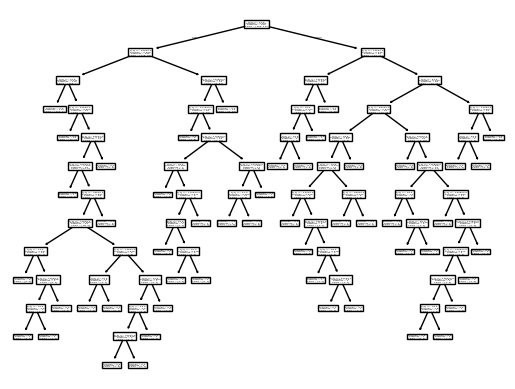

In [ ]:
from sklearn import tree
tree.plot_tree(Classifier)